Step 1: Loading data...
Data loaded: 1237 records

Step 2: Splitting data (80/20 train/test)...
Train: 989, Test: 248

Step 3: Training Prophet model...


12:49:11 - cmdstanpy - INFO - Chain [1] start processing
12:49:12 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully

Step 4: Generating predictions on test data...
MAE: $1753.84
RMSE: $2427.05
MAPE: 800.46%

Step 5: Creating 30-day future forecast...
30-day forecast:
           Date  Forecast_Sales  Lower_Bound  Upper_Bound  \
989  2017-03-29         1733.54     -2626.26      6282.09   
990  2017-03-30         1919.44     -2360.23      6580.15   
991  2017-03-31         2126.25     -2314.29      6483.93   
992  2017-04-01         1667.33     -2664.17      5800.26   
993  2017-04-02         1747.37     -2548.50      6255.75   
994  2017-04-03         1946.02     -2416.02      6244.81   
995  2017-04-04         1888.21     -2560.15      6141.59   
996  2017-04-05         1326.64     -2903.39      6079.21   
997  2017-04-06         1584.54     -2783.07      5989.55   
998  2017-04-07         1868.45     -2515.40      6236.69   
999  2017-04-08         1489.39     -2809.92      5625.00   
1000 2017-04-09         1649.66     -2478.15      5768.69   
1001 2017-04-10         1926

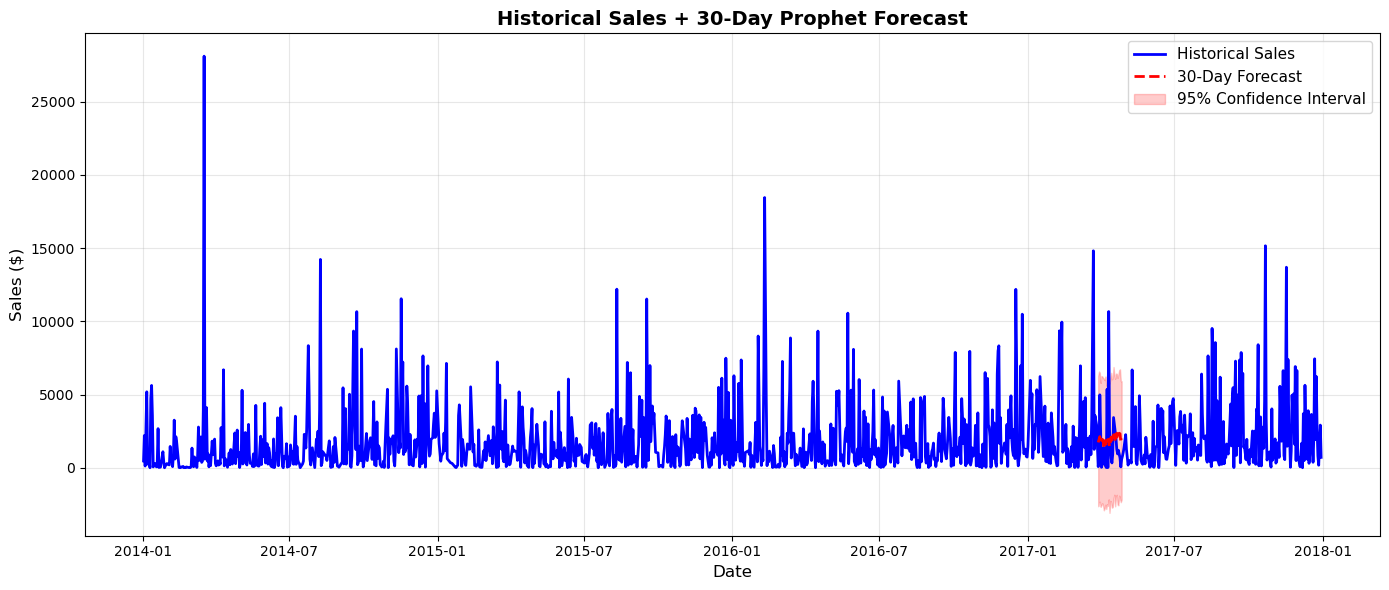

Chart saved: sales_forecast_chart.png

FORECAST COMPLETE!

Files generated for Power BI:
  1. prophet_forecast_30days.csv
  2. sales_actual_forecast_combined.csv
  3. weekly_forecast.csv
  4. forecast_summary.csv
  5. forecast_report.txt
  6. prophet_model.pkl
  7. sales_forecast_chart.png

Next Steps in Power BI:
  1. Get Data > CSV > prophet_forecast_30days.csv
  2. Create Line Chart
  3. X-Axis: Date
  4. Y-Axis: Forecast_Sales
  5. Add confidence interval band using Upper_Bound/Lower_Bound
  6. Combine with historical Revenue Trend chart

Forecast Summary:
                Metric               Value
        Forecast Start 2017-03-29 00:00:00
          Forecast End 2017-04-27 00:00:00
 Total 30-Day Forecast          $57,075.40
Average Daily Forecast           $1,902.51
  Highest Day Forecast           $2,361.22
   Lowest Day Forecast           $1,326.64
             Model MAE           $1,753.84
            Model RMSE           $2,427.05
            Model MAPE             800.46%
   

In [5]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Loading data...")
df = pd.read_csv('Superstore_Final_Clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
print(f"Data loaded: {len(daily_sales)} records")

print("\nStep 2: Splitting data (80/20 train/test)...")
train_size = int(len(daily_sales) * 0.8)
train_data = daily_sales[:train_size].copy()
test_data = daily_sales[train_size:].copy()
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

print("\nStep 3: Training Prophet model...")
best_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
best_model.fit(train_data)
print("Model trained successfully")

print("\nStep 4: Generating predictions on test data...")
future_test = best_model.make_future_dataframe(periods=len(test_data))
forecast_all = best_model.predict(future_test)

forecast_test = forecast_all.iloc[-len(test_data):].copy()
forecast_test = forecast_test.reset_index(drop=True)
test_data_reset = test_data.reset_index(drop=True)

mae = mean_absolute_error(test_data_reset['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test_data_reset['y'], forecast_test['yhat']))
mape = np.mean(np.abs((test_data_reset['y'] - forecast_test['yhat']) / test_data_reset['y'])) * 100

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

print("\nStep 5: Creating 30-day future forecast...")
future_30 = best_model.make_future_dataframe(periods=30)
forecast_30_all = best_model.predict(future_30)
forecast_30 = forecast_30_all.tail(30)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

forecast_30.columns = ['Date', 'Forecast_Sales', 'Lower_Bound', 'Upper_Bound']
forecast_30['Forecast_Sales'] = forecast_30['Forecast_Sales'].round(2)
forecast_30['Lower_Bound'] = forecast_30['Lower_Bound'].round(2)
forecast_30['Upper_Bound'] = forecast_30['Upper_Bound'].round(2)
forecast_30['Confidence_Interval'] = (forecast_30['Upper_Bound'] - forecast_30['Lower_Bound']).round(2)
forecast_30['Forecast_Type'] = 'Prophet'
forecast_30['Confidence_Level'] = 95

print("30-day forecast:")
print(forecast_30)

print("\nStep 6: Exporting to CSV (Power BI format)...")
forecast_30.to_csv('./', index=False)
print("Exported: prophet_forecast_30days.csv")

print("\nStep 7: Creating combined actual + forecast...")
historical = df.groupby('Order Date')['Sales'].sum().reset_index()
historical.columns = ['Date', 'Actual_Sales']
historical['Forecast_Sales'] = np.nan
historical['Lower_Bound'] = np.nan
historical['Upper_Bound'] = np.nan
historical['Forecast_Type'] = 'Actual'

forecast_combined = forecast_30[['Date', 'Forecast_Sales', 'Lower_Bound', 'Upper_Bound']].copy()
forecast_combined['Date'] = pd.to_datetime(forecast_combined['Date'])
forecast_combined['Actual_Sales'] = np.nan
forecast_combined['Forecast_Type'] = 'Forecast'

combined = pd.concat([historical, forecast_combined], ignore_index=True)
combined = combined.sort_values('Date').reset_index(drop=True)
combined.to_csv('./', index=False)
print("Exported: sales_actual_forecast_combined.csv")

print("\nStep 8: Creating weekly forecast...")
forecast_30['Date'] = pd.to_datetime(forecast_30['Date'])
forecast_30['Week'] = forecast_30['Date'].dt.strftime('%Y-W%U')

weekly_forecast = forecast_30.groupby('Week').agg({
    'Forecast_Sales': 'sum',
    'Lower_Bound': 'sum',
    'Upper_Bound': 'sum'
}).reset_index()
weekly_forecast.columns = ['Week', 'Weekly_Forecast', 'Weekly_Lower', 'Weekly_Upper']
weekly_forecast.to_csv('./', index=False)
print("Exported: weekly_forecast.csv")

print("\nStep 9: Creating forecast summary...")
summary_table = pd.DataFrame({
    'Metric': [
        'Forecast Start',
        'Forecast End',
        'Total 30-Day Forecast',
        'Average Daily Forecast',
        'Highest Day Forecast',
        'Lowest Day Forecast',
        'Model MAE',
        'Model RMSE',
        'Model MAPE',
        'Confidence Level'
    ],
    'Value': [
        str(forecast_30['Date'].min()),
        str(forecast_30['Date'].max()),
        f"${forecast_30['Forecast_Sales'].sum():,.2f}",
        f"${forecast_30['Forecast_Sales'].mean():,.2f}",
        f"${forecast_30['Forecast_Sales'].max():,.2f}",
        f"${forecast_30['Forecast_Sales'].min():,.2f}",
        f"${mae:,.2f}",
        f"${rmse:,.2f}",
        f"{mape:.2f}%",
        "95%"
    ]
})
summary_table.to_csv('./', index=False)
print("Exported: forecast_summary.csv")

print("\nStep 10: Saving model...")
with open('./', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved: prophet_model.pkl")

print("\nStep 11: Creating forecast report...")
report = f"""
PROPHET SALES FORECAST REPORT
{'='*60}

FORECAST PERIOD
Start Date: {forecast_30['Date'].min()}
End Date: {forecast_30['Date'].max()}
Days Forecasted: 30

FORECAST SUMMARY
Total 30-Day Sales: ${forecast_30['Forecast_Sales'].sum():,.2f}
Average Daily: ${forecast_30['Forecast_Sales'].mean():,.2f}
Min Daily: ${forecast_30['Forecast_Sales'].min():,.2f}
Max Daily: ${forecast_30['Forecast_Sales'].max():,.2f}

CONFIDENCE INTERVALS
Confidence Level: 95%
Average Interval: ${forecast_30['Confidence_Interval'].mean():,.2f}

MODEL PERFORMANCE
Training Days: {len(train_data)}
Test Days: {len(test_data)}
MAE: ${mae:,.2f}
RMSE: ${rmse:,.2f}
MAPE: {mape:.2f}%

WEEKLY BREAKDOWN
"""
for idx, row in weekly_forecast.iterrows():
    report += f"\n{row['Week']}: ${row['Weekly_Forecast']:,.2f}"

with open('./', 'w') as f:
    f.write(report)
print("Report saved: forecast_report.txt")

print("\nStep 12: Creating visualization...")
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_sales['ds'], daily_sales['y'], label='Historical Sales', color='blue', linewidth=2)
forecast_dates = pd.to_datetime(forecast_30['Date'])
ax.plot(forecast_dates, forecast_30['Forecast_Sales'], label='30-Day Forecast', color='red', linewidth=2, linestyle='--')
ax.fill_between(forecast_dates, forecast_30['Lower_Bound'], forecast_30['Upper_Bound'], alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_title('Historical Sales + 30-Day Prophet Forecast', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./', dpi=300)
plt.show()
print("Chart saved: sales_forecast_chart.png")

print("\n" + "="*60)
print("FORECAST COMPLETE!")
print("="*60)
print("\nFiles generated for Power BI:")
print("  1. prophet_forecast_30days.csv")
print("  2. sales_actual_forecast_combined.csv")
print("  3. weekly_forecast.csv")
print("  4. forecast_summary.csv")
print("  5. forecast_report.txt")
print("  6. prophet_model.pkl")
print("  7. sales_forecast_chart.png")

print("\nNext Steps in Power BI:")
print("  1. Get Data > CSV > prophet_forecast_30days.csv")
print("  2. Create Line Chart")
print("  3. X-Axis: Date")
print("  4. Y-Axis: Forecast_Sales")
print("  5. Add confidence interval band using Upper_Bound/Lower_Bound")
print("  6. Combine with historical Revenue Trend chart")

print("\nForecast Summary:")
print(summary_table.to_string(index=False))

In [6]:
import pandas as pd

df = pd.read_csv('./')

df['Actual_Sales'] = df['Actual_Sales'].fillna(df['Forecast_Sales'])
df['Forecast_Sales'] = df['Forecast_Sales'].fillna(df['Actual_Sales'])

df.to_csv('./', index=False)

print("Filled version created")
print(df)

Filled version created
            Date  Actual_Sales  Forecast_Sales  Lower_Bound  Upper_Bound  \
0     2014-01-02      468.9000        468.9000          NaN          NaN   
1     2014-01-03     2203.1510       2203.1510          NaN          NaN   
2     2014-01-04      119.8880        119.8880          NaN          NaN   
3     2014-01-06     5188.5200       5188.5200          NaN          NaN   
4     2014-01-07      601.0240        601.0240          NaN          NaN   
...          ...           ...             ...          ...          ...   
1262  2017-12-26      814.5940        814.5940          NaN          NaN   
1263  2017-12-27      177.6360        177.6360          NaN          NaN   
1264  2017-12-28     1657.3508       1657.3508          NaN          NaN   
1265  2017-12-29     2915.5340       2915.5340          NaN          NaN   
1266  2017-12-30      713.7900        713.7900          NaN          NaN   

     Forecast_Type  
0           Actual  
1           Actual  
2